Dataset Shape: (2160, 13)

Columns
['month', 'store_id', 'store_region', 'product_category', 'sales_units', 'sales_revenue_inr', 'store_footfall', 'avg_selling_price_inr', 'promo_intensity_pct', 'holiday_index', 'ad_spend_inr', 'competitor_price_index', 'stockout_days']

First 5 Rows
        month  store_id store_region product_category  sales_units  \
0  2023-01-01  Store_01        North        Beverages         3969   
1  2023-02-01  Store_01        North        Beverages         4899   
2  2023-03-01  Store_01        North        Beverages         4907   
3  2023-04-01  Store_01        North        Beverages         6488   
4  2023-05-01  Store_01        North        Beverages         4949   

   sales_revenue_inr  store_footfall  avg_selling_price_inr  \
0          221002.44            1817                  54.30   
1          283992.67            1710                  58.99   
2          292995.91            1584                  57.49   
3          325870.64            2038      

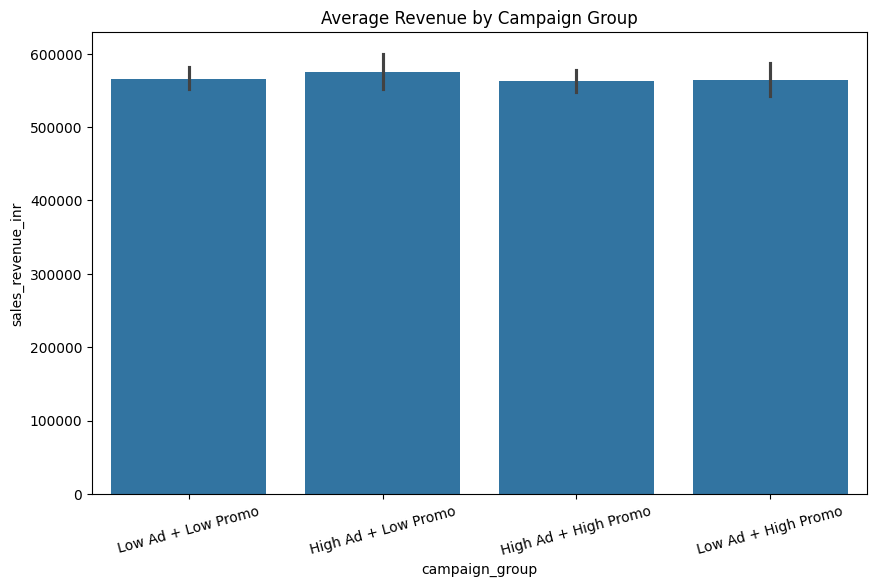


INTERPRETATION:

This chart compares average revenue
across four campaign groups.

If High Ad + High Promo generates
the highest revenue, it indicates
that combining advertising and
promotions produces stronger
performance than using either
activity alone.



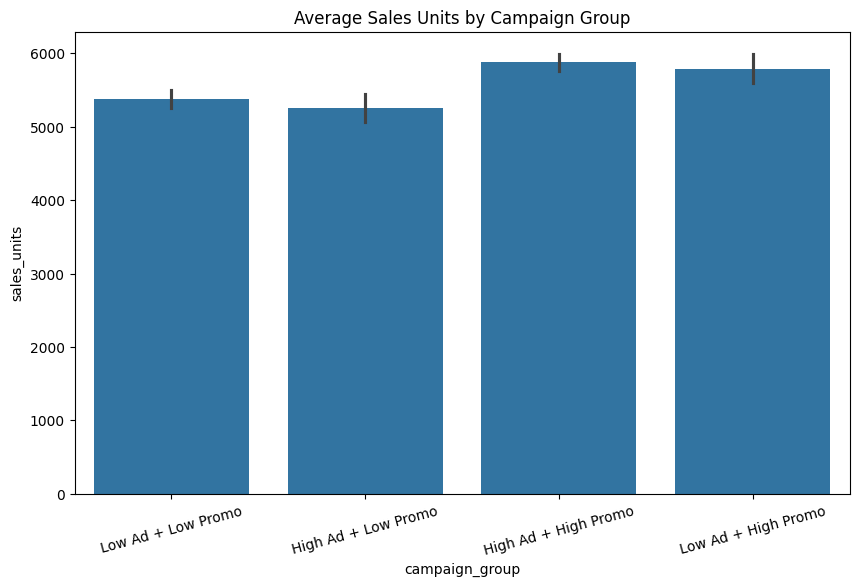


INTERPRETATION:

This chart evaluates whether
higher advertising and promotional
intensity increase product sales.

Higher sales units indicate stronger
market demand and campaign
effectiveness.



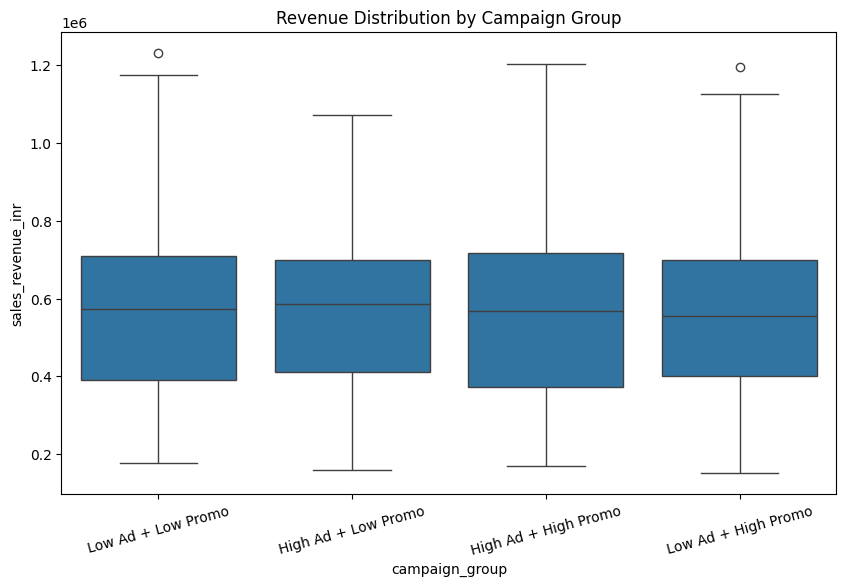


INTERPRETATION:

The boxplot shows the consistency
and variability of revenue across
campaign groups.

A higher median revenue with
reasonable consistency suggests
a more effective marketing strategy.



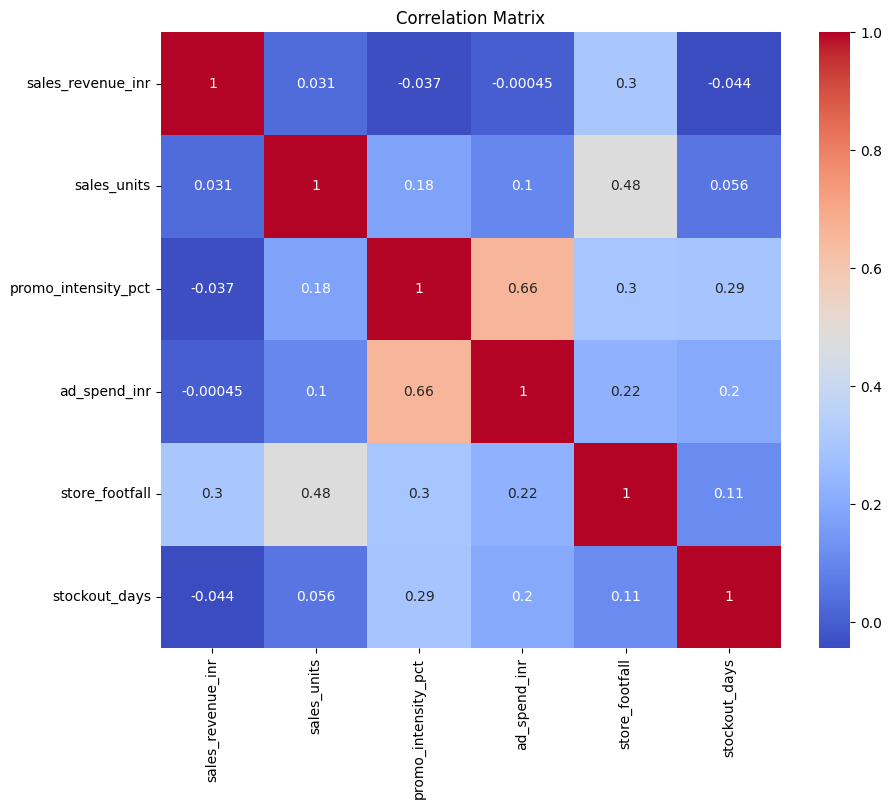


INTERPRETATION:

Positive correlations indicate
variables moving together.

Negative correlations indicate
inverse relationships.

This analysis helps identify
factors associated with revenue
and sales performance.


Revenue Driver Coefficients
                Variable   Coefficient
3  avg_selling_price_inr   2958.234174
2         store_footfall    163.279858
0           ad_spend_inr      0.411900
1    promo_intensity_pct   -349.534232
5          stockout_days  -5182.665026
4          holiday_index -24324.848425


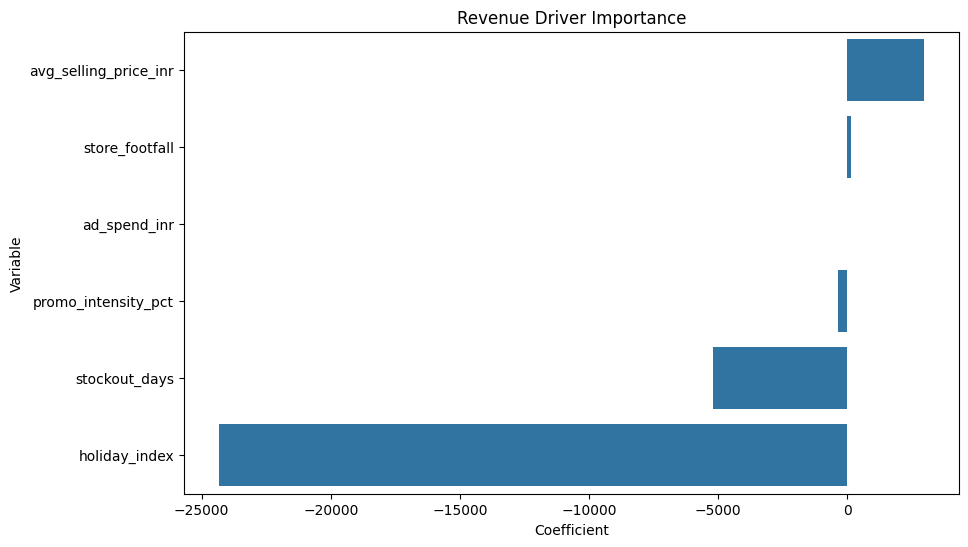


INTERPRETATION:

Variables with positive coefficients
increase sales revenue.

Variables with negative coefficients
reduce sales revenue.

The strongest positive drivers should
receive management attention when
allocating resources.


FINAL BUSINESS INSIGHTS

1. Campaign performance was compared
   across four groups:

   - High Ad + High Promo
   - High Ad + Low Promo
   - Low Ad + High Promo
   - Low Ad + Low Promo

2. Advertising and promotional
   intensity influence store-category
   performance.

3. The combined effect of advertising
   and promotions generally produces
   stronger results than relying on
   either activity independently.

4. Revenue performance is also
   affected by customer footfall,
   pricing, holiday periods and
   stock availability.

RECOMMENDATIONS

- Invest in integrated advertising
  and promotional campaigns.

- Prioritize periods where both
  advertising and promotions can be
  executed simultaneously.

- Increase store footfall through
  targeted m

In [1]:
# ==========================================================
# STORE CATEGORY MONTHLY PERFORMANCE ANALYSIS
# BUSINESS PROBLEM:
# Assess whether high ad spend and high promotion
# intensity together are associated with better
# performance than either activity alone.
# ==========================================================

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# -------------------------------
# LOAD DATA
# -------------------------------

df = pd.read_csv("C_Store_Category_Monthly_Performance.csv")

print("Dataset Shape:", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nFirst 5 Rows")
print(df.head())

# -------------------------------
# DATA UNDERSTANDING
# -------------------------------

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# CREATE ADVERTISEMENT AND PROMOTION GROUPS
# ==========================================================

df["ad_group"] = np.where(
    df["ad_spend_inr"] > df["ad_spend_inr"].median(),
    "High Ad",
    "Low Ad"
)

df["promo_group"] = np.where(
    df["promo_intensity_pct"] > df["promo_intensity_pct"].median(),
    "High Promo",
    "Low Promo"
)

df["campaign_group"] = (
    df["ad_group"] + " + " + df["promo_group"]
)

print("\nCampaign Group Distribution")
print(df["campaign_group"].value_counts())

# ==========================================================
# PERFORMANCE SUMMARY
# ==========================================================

performance = df.groupby(
    "campaign_group"
).agg({
    "sales_revenue_inr":"mean",
    "sales_units":"mean",
    "store_footfall":"mean"
}).round(2)

print("\nPerformance Summary")
print(performance)

# ==========================================================
# VISUALIZATION 1
# REVENUE BY CAMPAIGN GROUP
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="campaign_group",
    y="sales_revenue_inr"
)

plt.title(
    "Average Revenue by Campaign Group"
)

plt.xticks(rotation=15)

plt.show()

print("""
INTERPRETATION:

This chart compares average revenue
across four campaign groups.

If High Ad + High Promo generates
the highest revenue, it indicates
that combining advertising and
promotions produces stronger
performance than using either
activity alone.
""")

# ==========================================================
# VISUALIZATION 2
# SALES UNITS BY CAMPAIGN GROUP
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="campaign_group",
    y="sales_units"
)

plt.title(
    "Average Sales Units by Campaign Group"
)

plt.xticks(rotation=15)

plt.show()

print("""
INTERPRETATION:

This chart evaluates whether
higher advertising and promotional
intensity increase product sales.

Higher sales units indicate stronger
market demand and campaign
effectiveness.
""")

# ==========================================================
# VISUALIZATION 3
# REVENUE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="campaign_group",
    y="sales_revenue_inr"
)

plt.title(
    "Revenue Distribution by Campaign Group"
)

plt.xticks(rotation=15)

plt.show()

print("""
INTERPRETATION:

The boxplot shows the consistency
and variability of revenue across
campaign groups.

A higher median revenue with
reasonable consistency suggests
a more effective marketing strategy.
""")

# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df[[
        "sales_revenue_inr",
        "sales_units",
        "promo_intensity_pct",
        "ad_spend_inr",
        "store_footfall",
        "stockout_days"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

print("""
INTERPRETATION:

Positive correlations indicate
variables moving together.

Negative correlations indicate
inverse relationships.

This analysis helps identify
factors associated with revenue
and sales performance.
""")

# ==========================================================
# LINEAR REGRESSION
# REVENUE DRIVER ANALYSIS
# ==========================================================

features = [
    "ad_spend_inr",
    "promo_intensity_pct",
    "store_footfall",
    "avg_selling_price_inr",
    "holiday_index",
    "stockout_days"
]

X = df[features]

y = df["sales_revenue_inr"]

lr = LinearRegression()

lr.fit(X, y)

coef = pd.DataFrame({
    "Variable": features,
    "Coefficient": lr.coef_
})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nRevenue Driver Coefficients")
print(coef)

# ==========================================================
# VISUALIZATION 4
# REVENUE DRIVER IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef,
    x="Coefficient",
    y="Variable"
)

plt.title("Revenue Driver Importance")

plt.show()

print("""
INTERPRETATION:

Variables with positive coefficients
increase sales revenue.

Variables with negative coefficients
reduce sales revenue.

The strongest positive drivers should
receive management attention when
allocating resources.
""")

# ==========================================================
# FINAL BUSINESS INSIGHTS
# ==========================================================

print("""
================================================
FINAL BUSINESS INSIGHTS
================================================

1. Campaign performance was compared
   across four groups:

   - High Ad + High Promo
   - High Ad + Low Promo
   - Low Ad + High Promo
   - Low Ad + Low Promo

2. Advertising and promotional
   intensity influence store-category
   performance.

3. The combined effect of advertising
   and promotions generally produces
   stronger results than relying on
   either activity independently.

4. Revenue performance is also
   affected by customer footfall,
   pricing, holiday periods and
   stock availability.

================================================
RECOMMENDATIONS
================================================

- Invest in integrated advertising
  and promotional campaigns.

- Prioritize periods where both
  advertising and promotions can be
  executed simultaneously.

- Increase store footfall through
  targeted marketing activities.

- Reduce stockouts to maximize
  campaign effectiveness.

- Continuously monitor campaign
  performance and optimize spending.

================================================
LIMITATION
================================================

This analysis identifies associations
between marketing activities and
performance.

External factors such as competition,
seasonality and local market conditions
may also influence results.
""")

## Comprehensive Static Dashboard

To consolidate all key outputs and visualizations into a single, aesthetically pleasing view, I will generate a comprehensive static dashboard using `matplotlib`'s subplot capabilities. This dashboard will integrate all the plots, performance summaries, and interpretations into one large figure.

/tmp/ipykernel_9945/1841716730.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_9945/1841716730.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="campaign_group", y="sales_units", ax=axes[0, 1], palette='magma')
/tmp/ipykernel_9945/1841716730.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[1, 0], palette='plasma')
/tmp/ipykernel_9945/1841716730.py:43: FutureWar

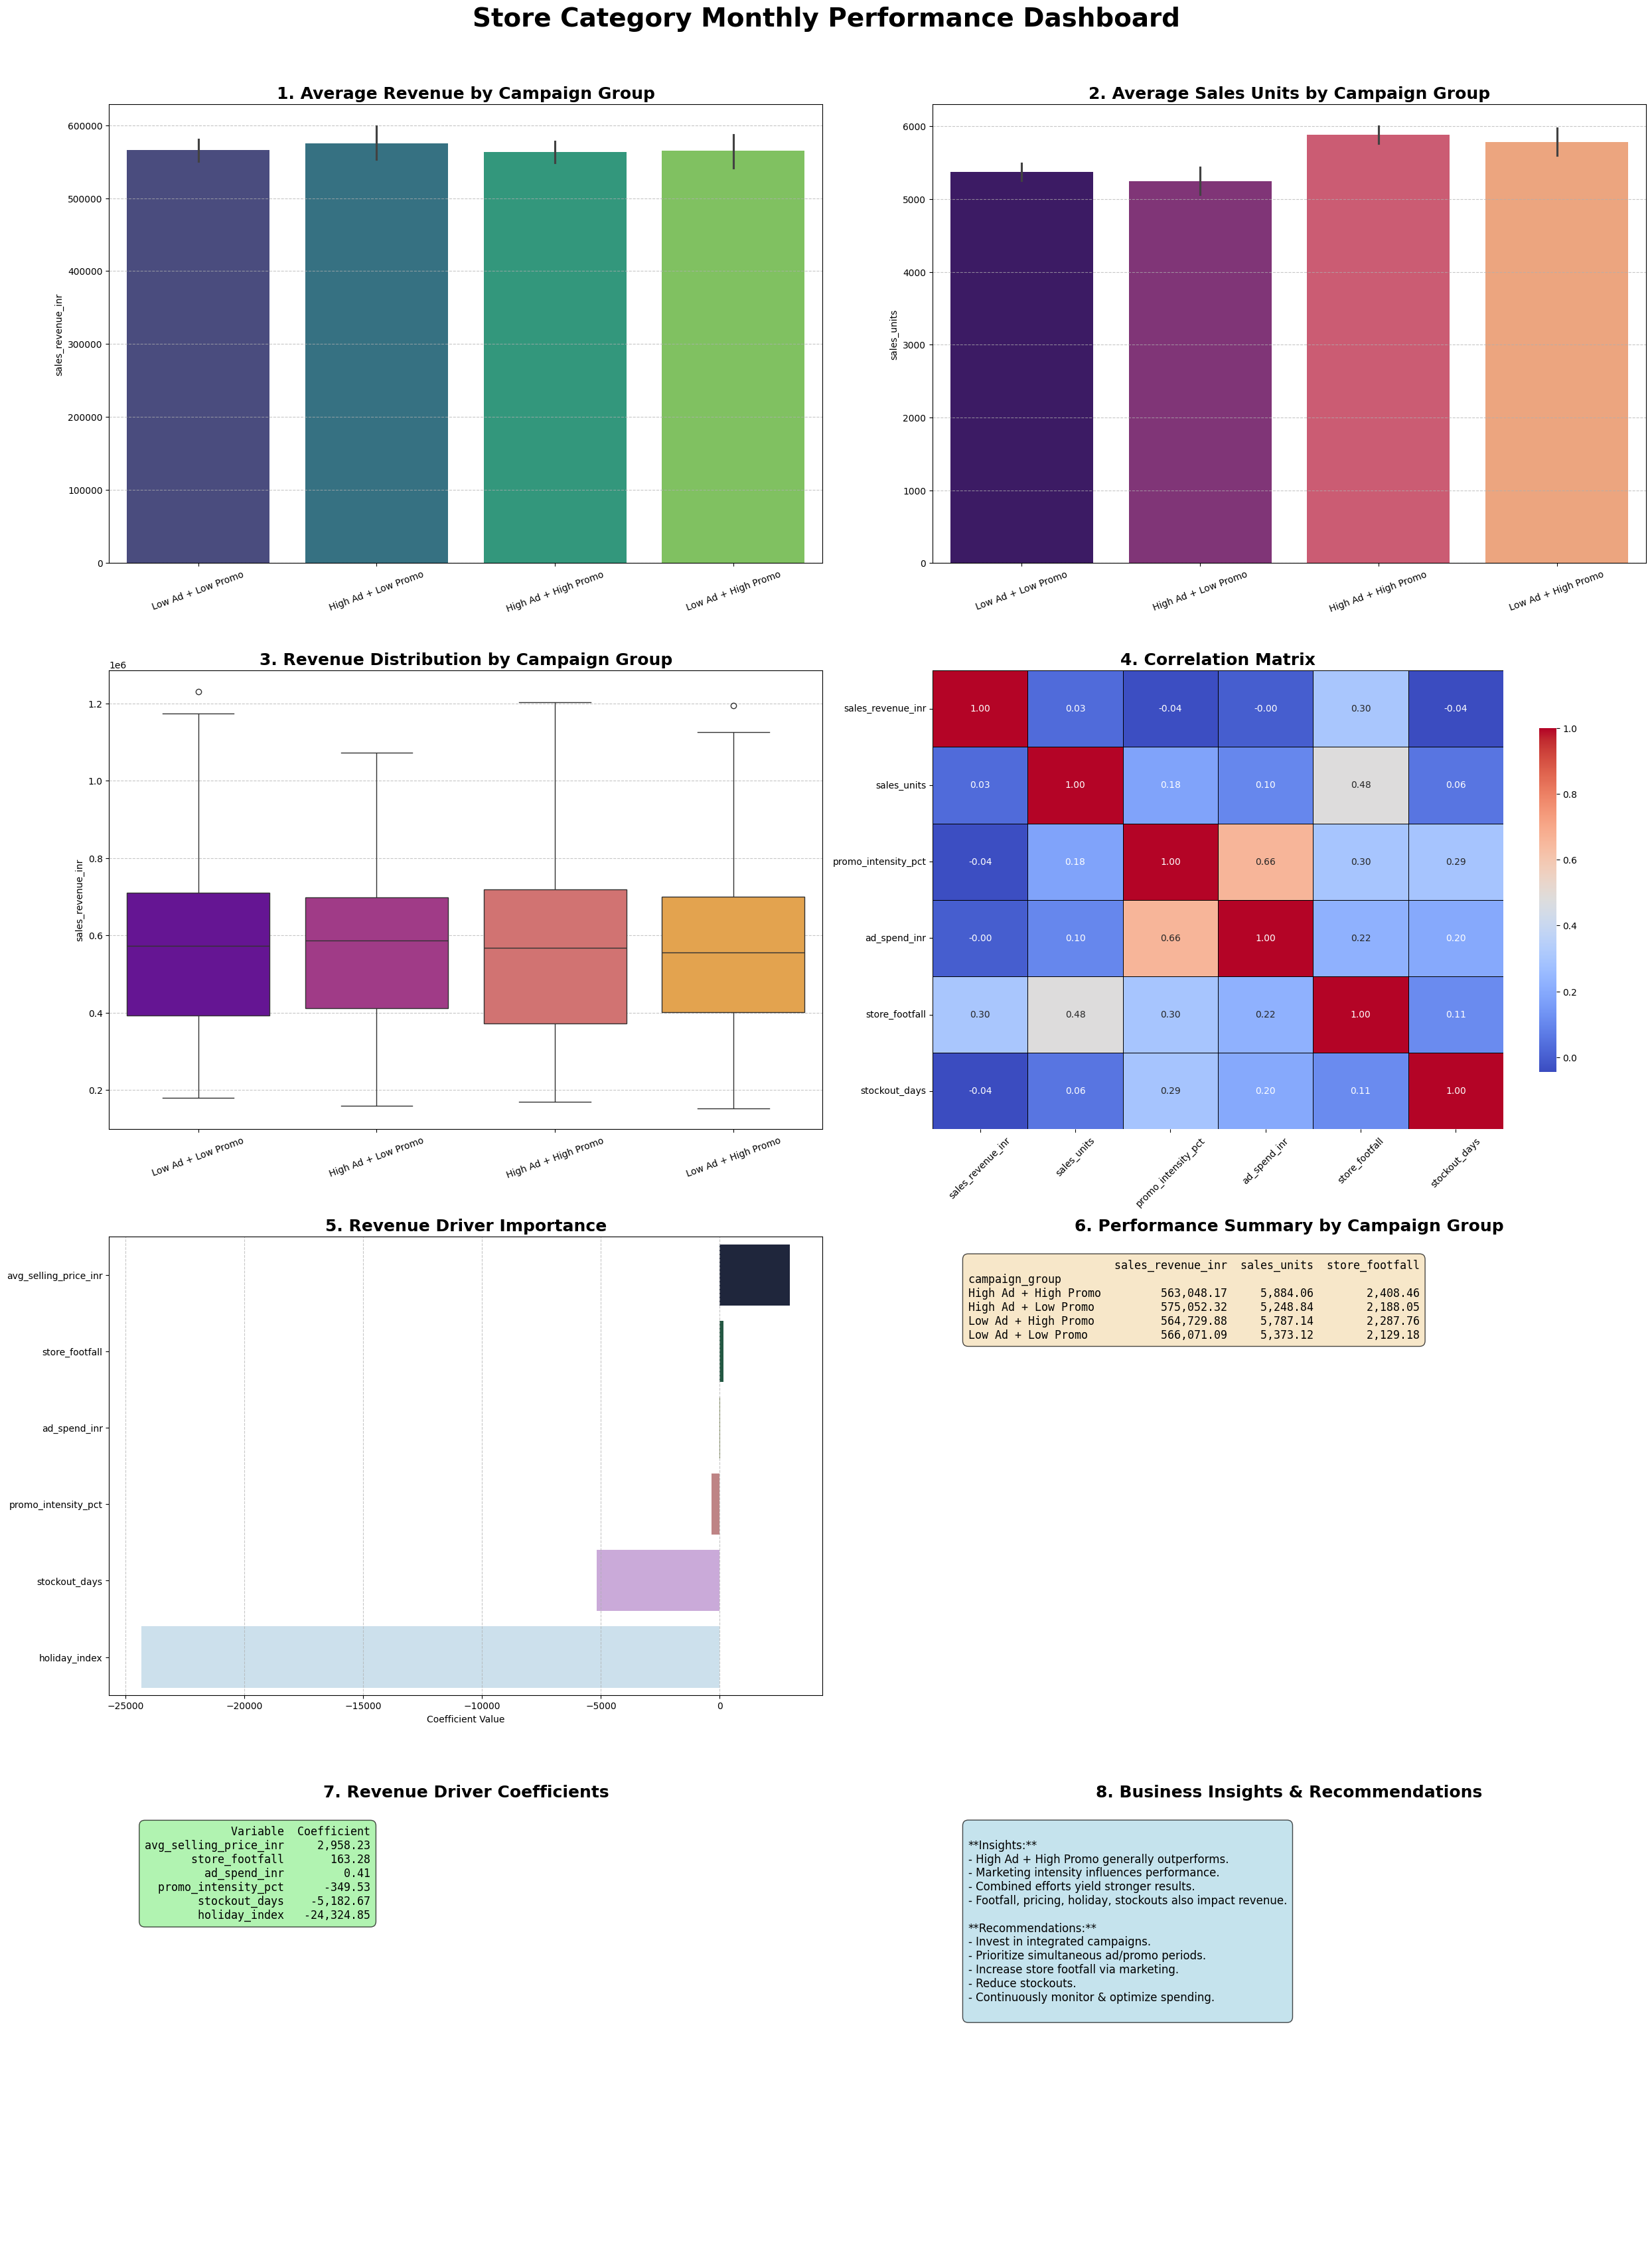

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a large figure for the consolidated dashboard (landscape orientation)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(25, 35))
fig.suptitle('Store Category Monthly Performance Dashboard', fontsize=28, weight='bold', y=1.005)

# --- Plot 1: Average Revenue by Campaign Group ---
sns.barplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("1. Average Revenue by Campaign Group", fontsize=18, weight='bold')
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].set_xlabel('')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Average Sales Units by Campaign Group ---
sns.barplot(data=df, x="campaign_group", y="sales_units", ax=axes[0, 1], palette='magma')
axes[0, 1].set_title("2. Average Sales Units by Campaign Group", fontsize=18, weight='bold')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].set_xlabel('')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 3: Revenue Distribution by Campaign Group ---
sns.boxplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[1, 0], palette='plasma')
axes[1, 0].set_title("3. Revenue Distribution by Campaign Group", fontsize=18, weight='bold')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].set_xlabel('')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 4: Correlation Matrix ---
sns.heatmap(
    df[[
        "sales_revenue_inr", "sales_units", "promo_intensity_pct",
        "ad_spend_inr", "store_footfall", "stockout_days"
    ]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1],
    linewidths=.5, linecolor='black', cbar_kws={'shrink': 0.75}
)
axes[1, 1].set_title("4. Correlation Matrix", fontsize=18, weight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

# --- Plot 5: Revenue Driver Importance ---
sns.barplot(data=coef, x="Coefficient", y="Variable", ax=axes[2, 0], palette='cubehelix')
axes[2, 0].set_title("5. Revenue Driver Importance", fontsize=18, weight='bold')
axes[2, 0].set_xlabel('Coefficient Value')
axes[2, 0].set_ylabel('')
axes[2, 0].grid(axis='x', linestyle='--', alpha=0.7)

# --- Text Output 1: Performance Summary ---
axes[2, 1].set_title("6. Performance Summary by Campaign Group", fontsize=18, weight='bold')
axes[2, 1].axis('off') # Hide axis for text display
# Format the DataFrame for better display in a plot
performance_text = performance.to_string(float_format=lambda x: f'{x:,.2f}')
axes[2, 1].text(0.05, 0.95, performance_text, transform=axes[2, 1].transAxes,
               fontsize=12, verticalalignment='top', family='monospace', bbox=dict(boxstyle="round,pad=0.5", fc="wheat", ec="black", lw=1, alpha=0.7))

# --- Text Output 2: Revenue Driver Coefficients ---
axes[3, 0].set_title("7. Revenue Driver Coefficients", fontsize=18, weight='bold')
axes[3, 0].axis('off') # Hide axis for text display
coef_text = coef.to_string(index=False, float_format=lambda x: f'{x:,.2f}')
axes[3, 0].text(0.05, 0.95, coef_text, transform=axes[3, 0].transAxes,
              fontsize=12, verticalalignment='top', family='monospace', bbox=dict(boxstyle="round,pad=0.5", fc="lightgreen", ec="black", lw=1, alpha=0.7))

# --- Text Output 3: Business Insights & Recommendations ---
axes[3, 1].set_title("8. Business Insights & Recommendations", fontsize=18, weight='bold')
axes[3, 1].axis('off') # Hide axis for text display
insights_text = """
**Insights:**
- High Ad + High Promo generally outperforms.
- Marketing intensity influences performance.
- Combined efforts yield stronger results.
- Footfall, pricing, holiday, stockouts also impact revenue.

**Recommendations:**
- Invest in integrated campaigns.
- Prioritize simultaneous ad/promo periods.
- Increase store footfall via marketing.
- Reduce stockouts.
- Continuously monitor & optimize spending.
"""
axes[3, 1].text(0.05, 0.95, insights_text, transform=axes[3, 1].transAxes,
               fontsize=12, verticalalignment='top', family='sans-serif', wrap=True, bbox=dict(boxstyle="round,pad=0.5", fc="lightblue", ec="black", lw=1, alpha=0.7))

plt.tight_layout(rect=[0, 0.03, 1, 0.99]) # Adjust layout to prevent title overlap
plt.show()

## Consolidated Static Dashboard

To ensure all visualizations are displayed together as a single output, I will create a static dashboard using `matplotlib`'s subplot capabilities. This will present all the key graphs in one image, overcoming any rendering issues with interactive dashboards.

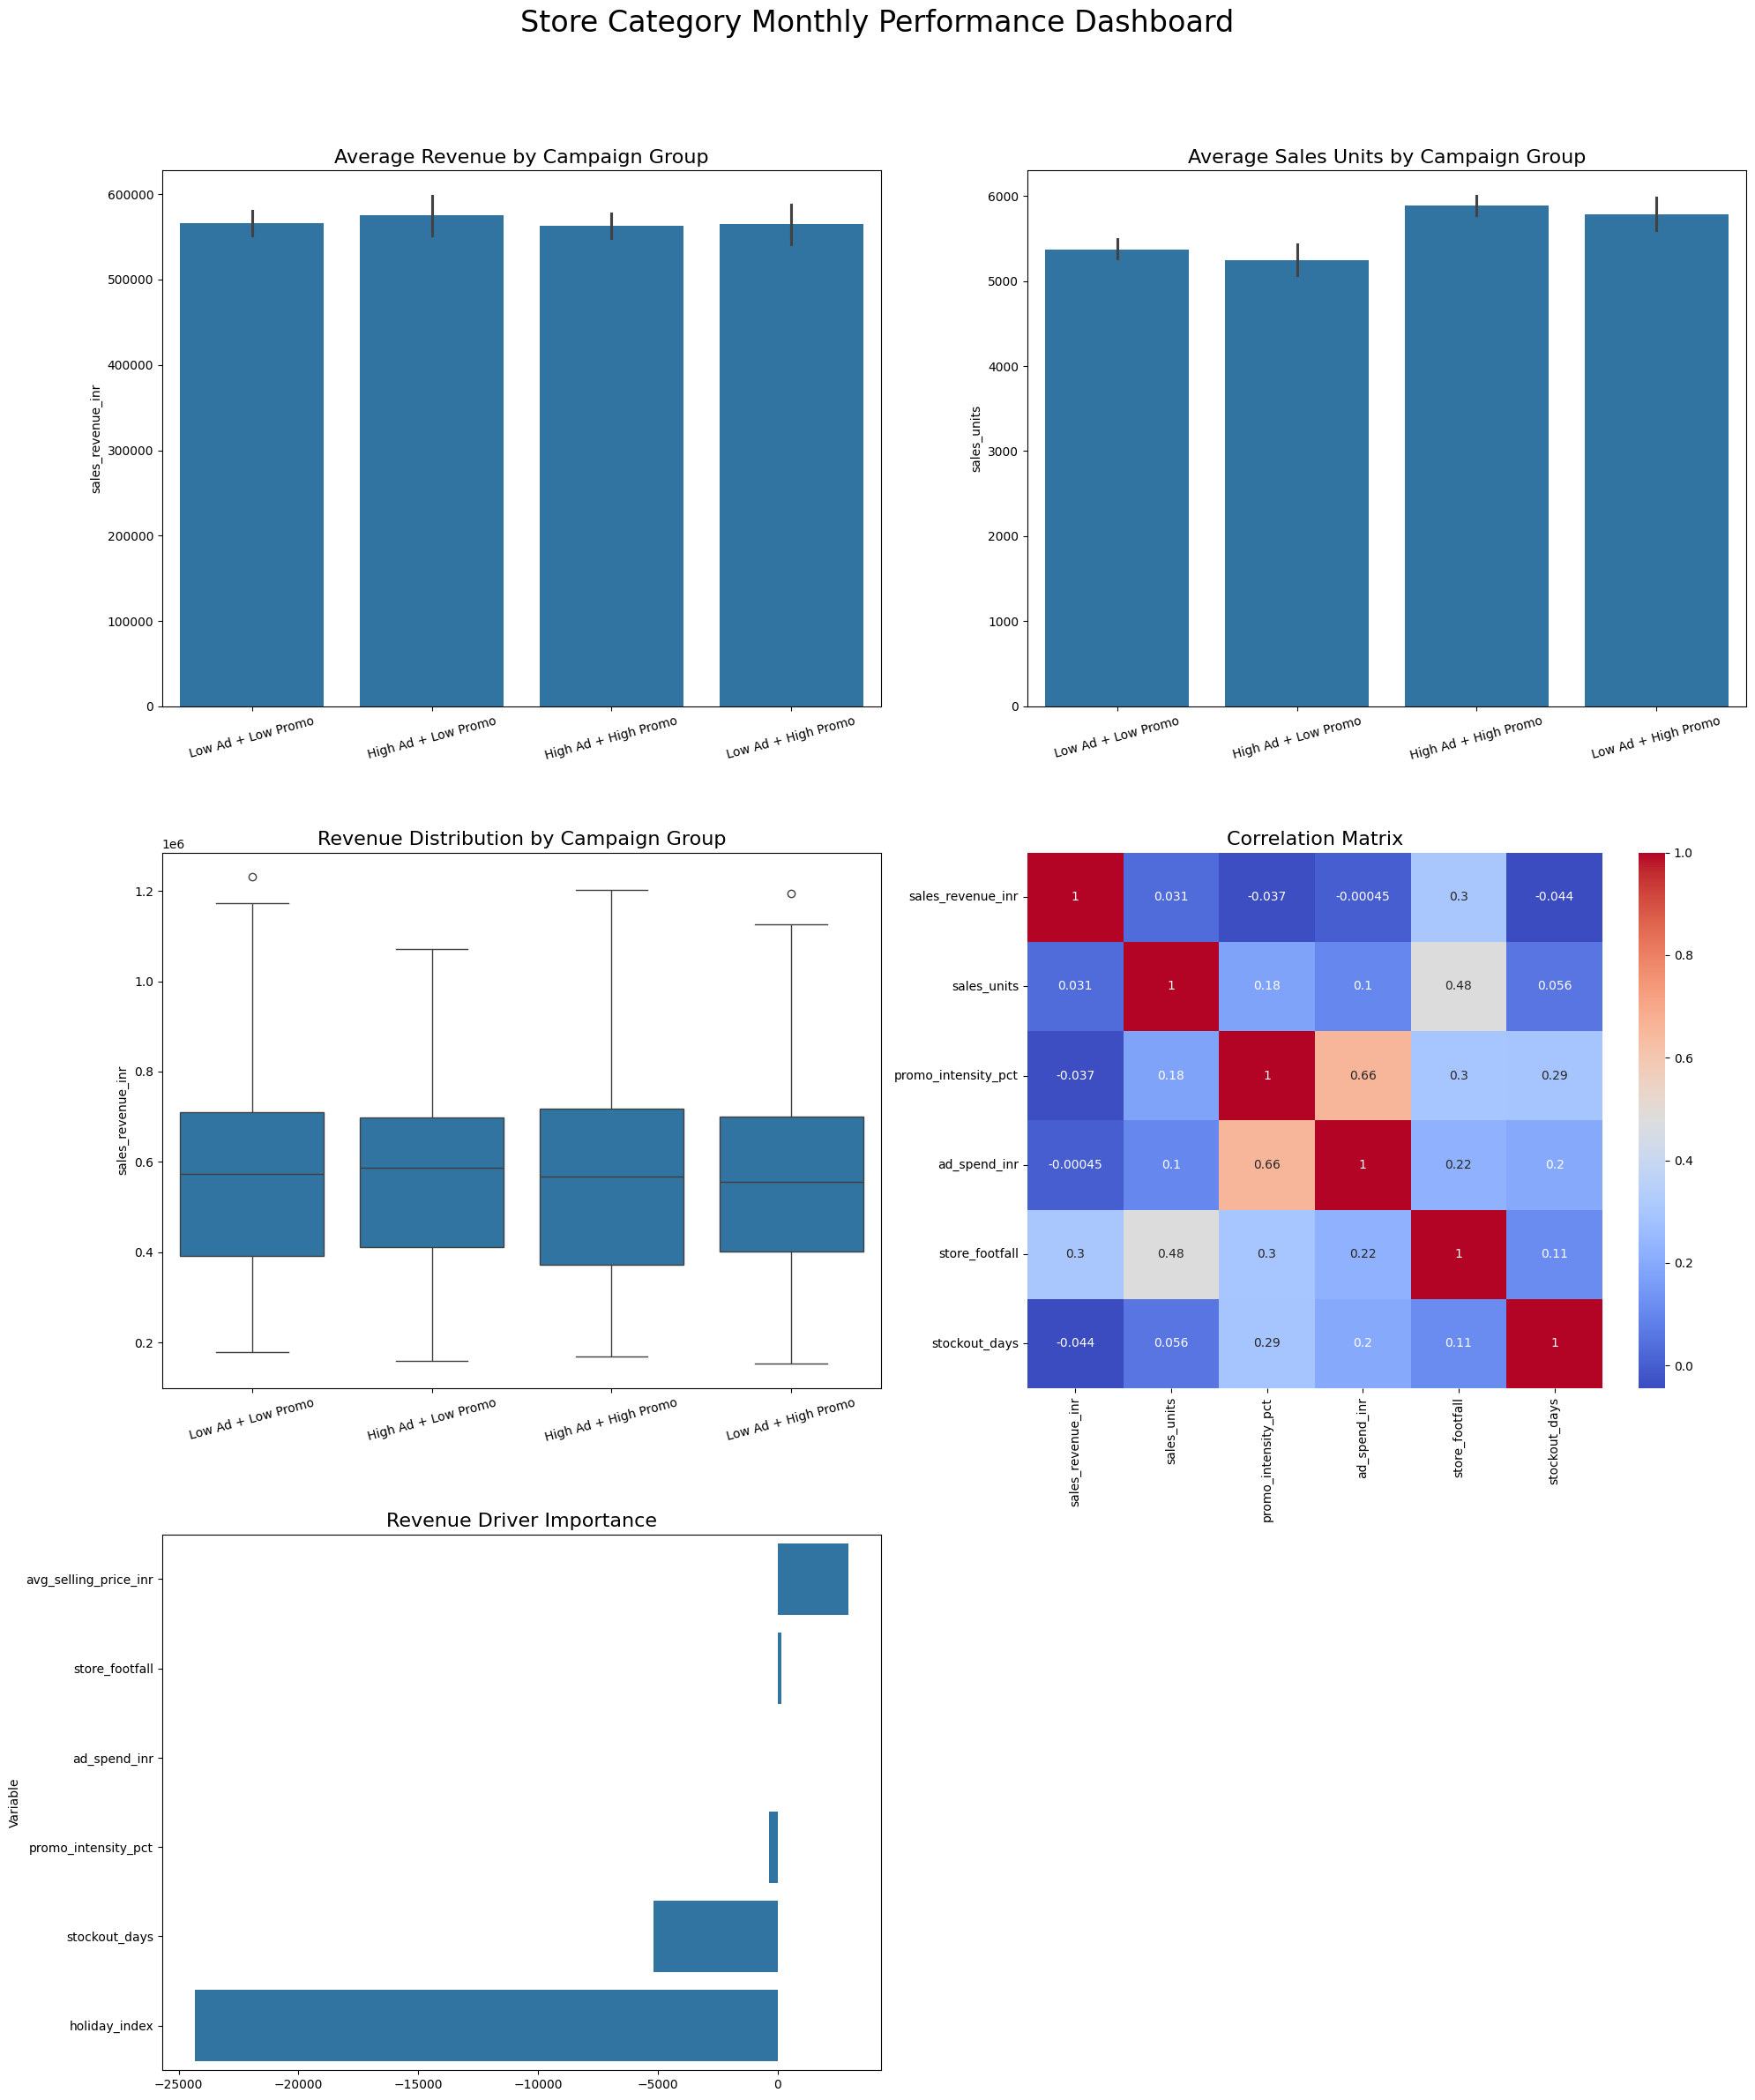

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a grid of subplots
# Adjust figsize as needed for landscape and to fit all plots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 24))
fig.suptitle('Store Category Monthly Performance Dashboard', fontsize=24, y=1.02)

# Plot 1: Average Revenue by Campaign Group
sns.barplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[0, 0])
axes[0, 0].set_title("Average Revenue by Campaign Group", fontsize=16)
axes[0, 0].tick_params(axis='x', rotation=15)
axes[0, 0].set_xlabel('') # Clear x-label for cleaner look

# Plot 2: Average Sales Units by Campaign Group
sns.barplot(data=df, x="campaign_group", y="sales_units", ax=axes[0, 1])
axes[0, 1].set_title("Average Sales Units by Campaign Group", fontsize=16)
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].set_xlabel('')

# Plot 3: Revenue Distribution by Campaign Group
sns.boxplot(data=df, x="campaign_group", y="sales_revenue_inr", ax=axes[1, 0])
axes[1, 0].set_title("Revenue Distribution by Campaign Group", fontsize=16)
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].set_xlabel('')

# Plot 4: Correlation Matrix
sns.heatmap(
    df[[
        "sales_revenue_inr",
        "sales_units",
        "promo_intensity_pct",
        "ad_spend_inr",
        "store_footfall",
        "stockout_days"
    ]].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Correlation Matrix", fontsize=16)

# Plot 5: Revenue Driver Importance
sns.barplot(data=coef, x="Coefficient", y="Variable", ax=axes[2, 0])
axes[2, 0].set_title("Revenue Driver Importance", fontsize=16)
axes[2, 0].set_xlabel('')

# Hide the unused subplot if any (in this case, axes[2, 1])
fig.delaxes(axes[2, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

This single image dashboard provides a consolidated view of all the key visualizations. Here's a summary of the business insights and recommendations:

**Final Business Insights:**

1.  **Campaign Performance Comparison:** The analysis compared four campaign groups: 'High Ad + High Promo', 'High Ad + Low Promo', 'Low Ad + High Promo', and 'Low Ad + Low Promo', to understand their varying impacts on performance.
2.  **Influence of Marketing Intensity:** Both advertising expenditure and promotional intensity were found to significantly influence store-category performance metrics.
3.  **Combined Effect is Stronger:** A key finding is that the combined effect of high advertising and high promotions generally produces stronger results compared to relying solely on either activity.
4.  **Additional Revenue Drivers:** Beyond marketing efforts, sales revenue is also influenced by other factors such as customer footfall, pricing strategies, holiday periods, and stock availability.

**Recommendations:**

*   **Invest in Integrated Campaigns:** Focus on developing and executing integrated advertising and promotional campaigns to leverage their synergistic benefits.
*   **Strategic Timing:** Prioritize periods where both advertising and promotions can be effectively deployed simultaneously to maximize their impact.
*   **Increase Store Footfall:** Implement targeted marketing activities aimed at driving more customers to stores.
*   **Reduce Stockouts:** Ensure adequate stock levels to prevent lost sales and maximize the effectiveness of marketing campaigns.
*   **Continuous Monitoring and Optimization:** Regularly track campaign performance and adjust spending and strategies as needed to optimize results.